# Setup

In [75]:
from pycose.messages.sign1message import Sign1Message
from qr_manager import sign_message, verify_message, encrypt_message, decrypt_message, sign_eddsa, verify_eddsa
from datetime import datetime
from PIL import Image
from pprint import pprint
from io import BytesIO
from pyzbar import pyzbar
import cbor2, zlib, base45, qrcode

from mosip_auth_sdk import MOSIPAuthenticator
from mosip_auth_sdk.models import DemographicsModel
from dynaconf import Dynaconf

from mosip import MOSIPUser

ImportError: cannot import name 'sign_eddsa' from 'qr_manager' (c:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\__init__.py)

# Fetch MOSIP Details

In [39]:
config = Dynaconf(settings_files=["./mosip/mosip_config.toml"], environments=False)
authenticator = MOSIPAuthenticator(config=config)

demographic_data = DemographicsModel(name=[{"language": "eng", "value": "James Ernest Tumalad Geraldo"}])

response = authenticator.kyc(
    individual_id="6149804723",
    individual_id_type="UIN",
    demographic_data=demographic_data,
    consent=True
)

response_body = response.json()

decrypted_response = authenticator.decrypt_response(response_body)

2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_partner.pem
2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_partner.pem
2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_partner.pem
2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_partner.pem
2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_partner.pem
2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_partner.pem
2026-04-06 13:32:35,666 - ./mosip/certs/authenticator.log - INFO - Creating certificate Object for the file Path: ./mosip/certs/ida_part

c:\Users\J4M3S\Desktop\MOSIP\.venv\Lib\site-packages\mosip_auth_sdk\_authenticator\utils\cryptoutil.py:104: CryptographyDeprecationWarning: Parsed a negative serial number, which is disallowed by RFC 5280. Loading this certificate will cause an exception in the next release of cryptography.
  return pkcs12.load_key_and_certificates(


2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authenticator.log - INFO - Received Auth Request for demographic.
2026-04-06 13:32:36,443 - ./mosip/certs/authen

In [43]:
print(decrypted_response.keys())
gender = decrypted_response["gender_eng"]
face = decrypted_response["face"]
name = decrypted_response["name_eng"]
phone = decrypted_response["phone"]
email = decrypted_response["email"]
dob = decrypted_response["dob"]

dict_keys(['gender_eng', 'face', 'name_eng', 'phone', 'email', 'dob'])


## Generate Legitimate QR

In [44]:
# User Information
_img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\residents\sample\face_compressed.jpg"

with open(_img_path, "rb") as file:
    image_bytes = file.read()

claim_169 = {
    1 : "6149804723",
    2 : 1.0,
    3 : "eng",
    4 : name,
    8 : dob,
    9 : gender,
    11 : email,
    12 : phone,
    16 : image_bytes,
    17 : 1,
    99 : 4
}

cbor_claim_169  = cbor2.dumps(claim_169)

info = {
    1 : "DCS",
    2 : int(datetime.now().timestamp()),
    169 : cbor_claim_169
}

cbor_info = cbor2.dumps(info)

pprint(claim_169)
print()
pprint(info)

{1: '6149804723',
 2: 1.0,
 3: 'eng',
 4: 'James Ernest Tumalad Geraldo',
 8: '2001/09/15',
 9: 'Male',
 11: 'jtgeraldo@up.edu.ph',
 12: '9760406462',
 16: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00'
     b'\xff\xdb\x00C\x00P7<F<2PFAFZUP_x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff'
     b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
     b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
     b'\xff\xff\xff\xff\xff\xff\xc0\x00\x0b\x08\x00-\x00-\x01\x01'
     b'\x11\x00\xff\xc4\x00\x19\x00\x00\x03\x01\x01\x01\x00\x00\x00\x00'
     b'\x00\x00\x00\x00\x00\x00\x00\x02\x03\x04\x00\x01\x05\xff\xc4\x00'
     b'\x1f\x10\x00\x02\x02\x02\x03\x00\x03\x00\x00\x00\x00\x00\x00\x00'
     b'\x00\x00\x01\x11\x00\x02\x03!\x121A\x042Q\xff\xda\x00\x08\x01\x01'
     b'\x00\x00?\x00*\x01La\xce\x1b\xd4\xfb9\x06\xd6\x03\xb3\x07\x98>'
     b'\xc5\xde\xa7\x91\x96\xdc\x04\xd3\x93\xe4\x1cl\xb8\x88f\xab\x181H&'
     b"\x99\x82\x83\xea0\x15)\xf1\xc05\x06\x

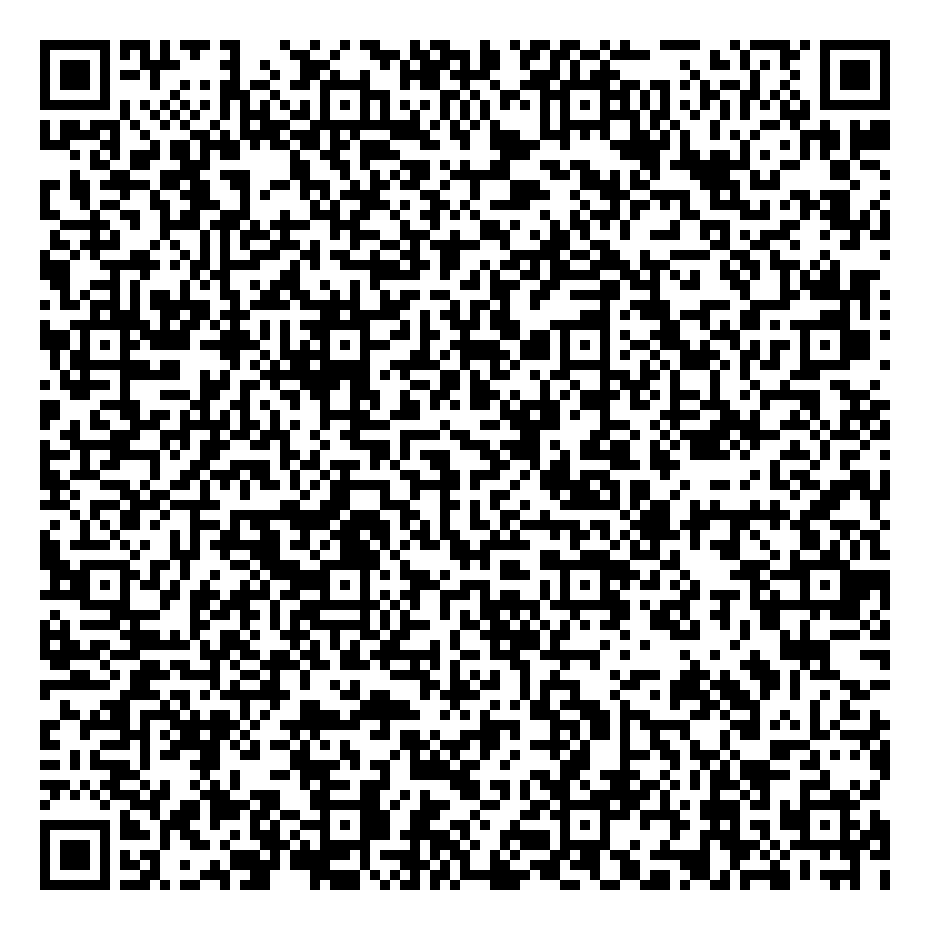

In [ ]:
# Generate QR
# s_msg = sign_message(cbor_info)
s_msg = sign_eddsa(cbor_info)

# e_msg = encrypt_message(s_msg)

# c_msg = zlib.compress(e_msg)
c_msg = zlib.compress(s_msg)

b45_msg = base45.b45encode(c_msg).decode()

qr = qrcode.make(b45_msg)

buffer = BytesIO()
qr.save(buffer, format="JPEG")
buffer.seek(0)

qr

## Generate Tampered QR

In [57]:
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\New_Sample\QR_1.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
decoded_b45

b'x\x9c\x93\x99\x9dcP\xce4-.W\xb37j\xe3Z\xc1\xbd\xbe\xf7\xfa\x8d\xc5\x92/\xc4\x1f\xccd\xca\x97m87\xb3\xff\xe9\xe16;\xe1\xa4\xc5\xd5g\xa6\x0bw_\xbe\x93\xf6 "SRL[\xbe\xc6):\xabk\xcd\x9cb\xee\xc5\x8c\xc9.\xce\xc1LR\x99\x97\xdd\x8b%VF2.Y\xcd\x98efhbia`bnd\xcc\xf4\xdb\xfe\x03\x03\x180\'\xa7\xe6\xa5\xb3T\xc8x%\xe6\xa6\x16+\xb8\x16\xe5\xa5\x16\x97(\x84\x94\xe6&\xe6$\xa6(\xb8\xa7\x16%\xe6\xa4\xe4sd\x19\x19\x18\x18\xea\x1bX\xea\x1b\x9ar\xa6\xf8&\xe6\xa4r\x17g\x95\xa4C$\x1dJ\x0b\xf4RSJ\xf5\n2x\xb2,\xcd\xcd\x0cL\x0c\xccL\xcc\x8c\x04"\x19u\xff\xdf\xf8\xff\x80A\xc0\xcb\xcd\xd3\x8d\x81\x91\x91\x81\x81\x11\x08\x19\xfe\xdffpf\x080\xb7q\xb31\npst\x8b\n\r\x88\xaf8\xd1T\x91\x97W\xf1u\xfd\xce\x89\'\xfe\x13\x07\x0e0ps0\xe82\xe822\n2\xfc?\xc2 \t\xf4\x06#\xc8\n8`bfa`d\x05J\xc9\x0b0011130\xc3\xa5\x80Z\x98\x98\x15\x85\x0c\x1dY\x8c\x02\xff\xdfb\xe0\x00\xe9\xb3g\xd0b\xf4I<\'}\xe5\xb7%\xdb5\xe6\xcd\xec3\xec\x8e\xde[>q\xda\x1d\x96\xcb\x93\x9f\xc8\xe4\xec\xe8H[-a\xe8\xa16\xb3\xa9\xf9\x95\x81\xa8\xe6\xc7\x03\xa6lg\x

### Changing a byte in QR.

In [58]:
mutable = bytearray(decoded_b45)
mutable[0] ^= 0x01
tampered_bytes = bytes(mutable)
tampered_bytes

b'y\x9c\x93\x99\x9dcP\xce4-.W\xb37j\xe3Z\xc1\xbd\xbe\xf7\xfa\x8d\xc5\x92/\xc4\x1f\xccd\xca\x97m87\xb3\xff\xe9\xe16;\xe1\xa4\xc5\xd5g\xa6\x0bw_\xbe\x93\xf6 "SRL[\xbe\xc6):\xabk\xcd\x9cb\xee\xc5\x8c\xc9.\xce\xc1LR\x99\x97\xdd\x8b%VF2.Y\xcd\x98efhbia`bnd\xcc\xf4\xdb\xfe\x03\x03\x180\'\xa7\xe6\xa5\xb3T\xc8x%\xe6\xa6\x16+\xb8\x16\xe5\xa5\x16\x97(\x84\x94\xe6&\xe6$\xa6(\xb8\xa7\x16%\xe6\xa4\xe4sd\x19\x19\x18\x18\xea\x1bX\xea\x1b\x9ar\xa6\xf8&\xe6\xa4r\x17g\x95\xa4C$\x1dJ\x0b\xf4RSJ\xf5\n2x\xb2,\xcd\xcd\x0cL\x0c\xccL\xcc\x8c\x04"\x19u\xff\xdf\xf8\xff\x80A\xc0\xcb\xcd\xd3\x8d\x81\x91\x91\x81\x81\x11\x08\x19\xfe\xdffpf\x080\xb7q\xb31\npst\x8b\n\r\x88\xaf8\xd1T\x91\x97W\xf1u\xfd\xce\x89\'\xfe\x13\x07\x0e0ps0\xe82\xe822\n2\xfc?\xc2 \t\xf4\x06#\xc8\n8`bfa`d\x05J\xc9\x0b0011130\xc3\xa5\x80Z\x98\x98\x15\x85\x0c\x1dY\x8c\x02\xff\xdfb\xe0\x00\xe9\xb3g\xd0b\xf4I<\'}\xe5\xb7%\xdb5\xe6\xcd\xec3\xec\x8e\xde[>q\xda\x1d\x96\xcb\x93\x9f\xc8\xe4\xec\xe8H[-a\xe8\xa16\xb3\xa9\xf9\x95\x81\xa8\xe6\xc7\x03\xa6lg\x

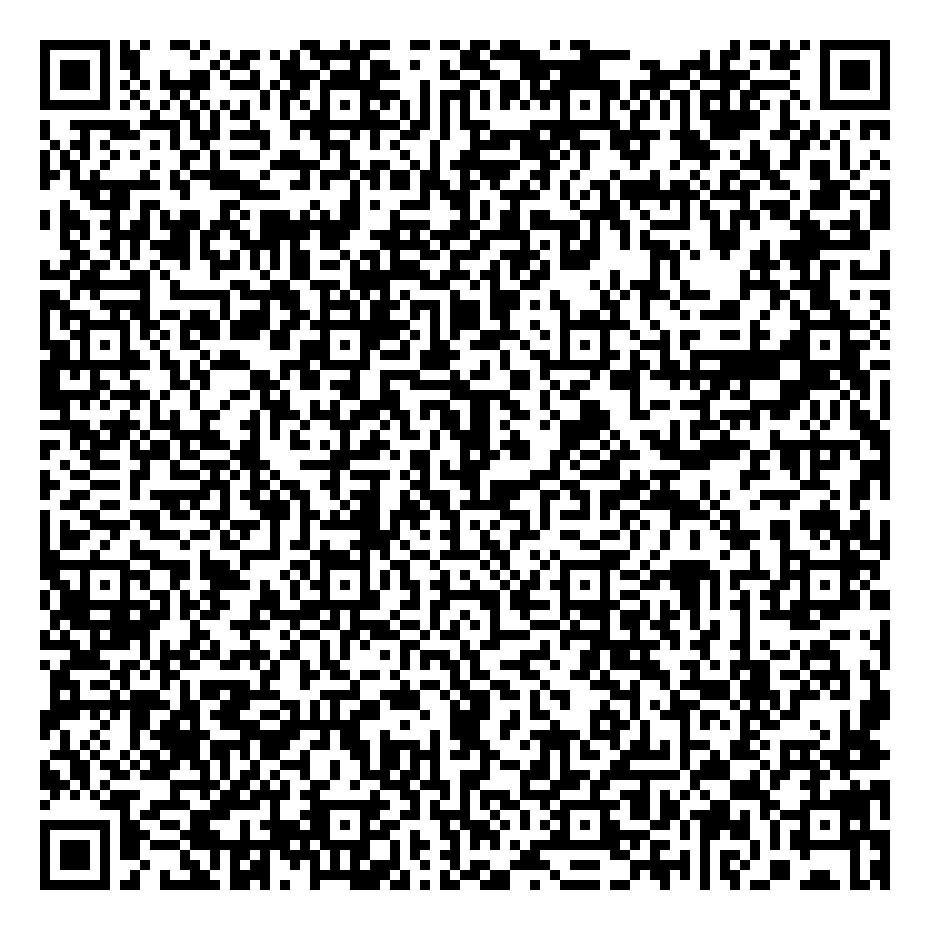

In [59]:
qr = qrcode.make(tampered_bytes)

buffer = BytesIO()
qr.save(buffer, format="JPEG")
buffer.seek(0)

qr

### Tampering QR

In [74]:
decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
message = verify_message(uncompressed)
cbor_data = cbor2.loads(message)
claim169 = cbor2.loads(cbor_data[169])
pprint(cbor_data)
pprint(claim169)

{1: 'DCS',
 2: 1775454067,
 169: b'\xab\x01j6149804723\x02\xfb?\xf0\x00\x00\x00\x00\x00\x00\x03ceng'
      b'\x04x\x1cJames Ernest Tumalad Geraldo\x08j2001/09/15\tdMale\x0bsjtger'
      b'aldo@up.edu.ph\x0cj9760406462\x10Y\x01-\xff\xd8\xff\xe0\x00\x10JFIF'
      b'\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00P7<F<2PFAFZUP'
      b'_x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xc0\x00\x0b\x08\x00-\x00-\x01\x01\x11\x00\xff\xc4\x00\x19'
      b'\x00\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
      b'\x00\x02\x03\x04\x00\x01\x05\xff\xc4\x00\x1f\x10\x00\x02\x02\x02'
      b'\x03\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x11\x00\x02'
      b'\x03!\x121A\x042Q\xff\xda\x00\x08\x01\x01\x00\x00?\x00*\x01La\xce\x1b'
      b'\xd4\xfb9\x06\xd6\x03\xb3\x07\x98>\xc5\xde\xa7\x91\x96\xdc'
      

In [62]:
cbor_s_msg[1] = "PH"

## Reading QR

{1: 'DCS',
 2: 1775454067,
 169: b'\xab\x01j6149804723\x02\xfb?\xf0\x00\x00\x00\x00\x00\x00\x03ceng'
      b'\x04x\x1cJames Ernest Tumalad Geraldo\x08j2001/09/15\tdMale\x0bsjtger'
      b'aldo@up.edu.ph\x0cj9760406462\x10Y\x01-\xff\xd8\xff\xe0\x00\x10JFIF'
      b'\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00P7<F<2PFAFZUP'
      b'_x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xc0\x00\x0b\x08\x00-\x00-\x01\x01\x11\x00\xff\xc4\x00\x19'
      b'\x00\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
      b'\x00\x02\x03\x04\x00\x01\x05\xff\xc4\x00\x1f\x10\x00\x02\x02\x02'
      b'\x03\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x11\x00\x02'
      b'\x03!\x121A\x042Q\xff\xda\x00\x08\x01\x01\x00\x00?\x00*\x01La\xce\x1b'
      b'\xd4\xfb9\x06\xd6\x03\xb3\x07\x98>\xc5\xde\xa7\x91\x96\xdc'
      

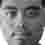

In [56]:
# Check signature
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\New_Sample\QR_1.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
# d_msg = decrypt_message(uncompressed)
# s_msg = verify_message(d_msg)
s_msg = verify_message(uncompressed)
cbor_s_msg = cbor2.loads(s_msg)
pprint(cbor_s_msg)
cbor_claim_169 = cbor2.loads(cbor_s_msg[169])
print()
pprint(cbor_claim_169)
img = Image.open(BytesIO(cbor_claim_169[16]))
img

# Test Cases

## CASE 1: Legitimate QR
QR verification passes, and resident exist in the database

{1: 'DCS',
 2: 1774242708.77429,
 169: b'\xa4\x01j6149804723\x10Y\x01-\xff\xd8\xff\xe0\x00\x10JFIF\x00'
      b'\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00P7<F<2PFAFZUP_'
      b'x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xc0'
      b'\x00\x0b\x08\x00-\x00-\x01\x01\x11\x00\xff\xc4\x00\x19\x00'
      b'\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
      b'\x02\x03\x04\x00\x01\x05\xff\xc4\x00\x1f\x10\x00\x02\x02\x02\x03'
      b'\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x11\x00\x02\x03!\x121A'
      b'\x042Q\xff\xda\x00\x08\x01\x01\x00\x00?\x00*\x01La\xce\x1b\xd4'
      b'\xfb9\x06\xd6\x03\xb3\x07\x98>\xc5\xde\xa7\x91\x96\xdc\x04'
      b'\xd3\x93\xe4\x1cl\xb8\x88f\xab\x181H&\x99\x82\x83\xea0\x15)'
      b'\xf1\xc05\x06\xcc\xcd\x93\xea\xa2P3 \'\x0c\xac\xe8\xa8\x04"\xe2'
      b'\xeeI\x04

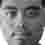

In [42]:
# Case 1
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\QR_1.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
d_msg = decrypt_message(uncompressed)
s_msg = verify_message(d_msg)
cbor_s_msg = cbor2.loads(s_msg)
pprint(cbor_s_msg)
cbor_claim_169 = cbor2.loads(cbor_s_msg[169])
print()
pprint(cbor_claim_169)
img = Image.open(BytesIO(cbor_claim_169[16]))
img

## CASE 2: QR Spoofing
QR verification passes, but resident fails the OIC face verification

## CASE 3: Tampered QR
QR verification fails because the signature does not match the payload

### Byte Flip

In [53]:
# Case 3
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\QR_3_byteflip.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
d_msg = decrypt_message(uncompressed)
s_msg = verify_message(d_msg)
cbor_s_msg = cbor2.loads(s_msg)
pprint(cbor_s_msg)
cbor_claim_169 = cbor2.loads(cbor_s_msg[169])
print()
pprint(cbor_claim_169)
img = Image.open(BytesIO(cbor_claim_169[16]))
img

ValueError: Invalid base45 string

## CASE 4: Legitimate PhilSys/MOSIP QR
QR cannot be verified, but MOSIP Authentication passes and resident exists in the database

## CASE 5: Legitimate QR but not in Database
MOSIP Authentication passes, but resident is not registered in the database

## CASE 6: Invalid QR
QR not generated by the LGU